# Final Project: Look at the data

In [1]:
import gradio as gr                                                 #For creating interactive web interfaces
import IPython.display as ipd                                       #For displaying audio in Jupyter notebooks
import librosa                                                      #For audio processing                    
import matplotlib.pyplot as plt                                     #For creating plots 
import numpy as np                                                  #For numerical operations
import os                                                           #For interacting with the operating system
import pandas as pd                                                 #For data manipulation and analysis 
import seaborn as sns                                               #For statistical data visualization
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import tensorflow as tf
import time
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from tomlkit import datetime
from tqdm import tqdm


In [2]:
# Set the path to data
DATA_PATH = "/Users/livajuliesmidt/Desktop/ML/AppliedML2026/FinalProject_Liva/FP_data"

dev_labels = pd.read_csv(f"{DATA_PATH}/FSD50K.ground_truth/dev.csv")
eval_labels = pd.read_csv(f"{DATA_PATH}/FSD50K.ground_truth/eval.csv")


dev_labels.head()

,fname,labels,mids,split
0,64760,"Electric_guitar,Guitar,Plucked_string_instrume...","/m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf",train
1,16399,"Electric_guitar,Guitar,Plucked_string_instrume...","/m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf",train
2,16401,"Electric_guitar,Guitar,Plucked_string_instrume...","/m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf",train
3,16402,"Electric_guitar,Guitar,Plucked_string_instrume...","/m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf",train
4,16404,"Electric_guitar,Guitar,Plucked_string_instrume...","/m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf",train


In [3]:
#Devide the dev set into train and val
train_labels = dev_labels[dev_labels["split"] == "train"]
val_labels = dev_labels[dev_labels["split"] == "val"]
train_labels.head()

,fname,labels,mids,split
0,64760,"Electric_guitar,Guitar,Plucked_string_instrume...","/m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf",train
1,16399,"Electric_guitar,Guitar,Plucked_string_instrume...","/m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf",train
2,16401,"Electric_guitar,Guitar,Plucked_string_instrume...","/m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf",train
3,16402,"Electric_guitar,Guitar,Plucked_string_instrume...","/m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf",train
4,16404,"Electric_guitar,Guitar,Plucked_string_instrume...","/m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf",train


In [4]:
# Get all unique classes
all_classes = sorted(train_labels["labels"].str.split(",").explode().unique())

def get_samples_for_class(class_name, n=5):
    mask = train_labels["labels"].str.contains(class_name, regex=False)
    samples = train_labels[mask].sample(min(n, mask.sum()), random_state=np.random.randint(1000))
    return samples

def plot_waveform_and_mel(filepath):
    audio, sr = librosa.load(filepath, sr=22050, duration=10.0)
    time = np.linspace(0, len(audio)/sr, len(audio))

    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=64)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    fig, axes = plt.subplots(2, 1, figsize=(10, 5))

    # Waveform
    axes[0].plot(time, audio, color="steelblue", linewidth=0.5)
    axes[0].set_xlabel("Time (s)")
    axes[0].set_ylabel("Amplitude")
    axes[0].set_title("Waveform")

    # Mel spectrogram
    img = axes[1].imshow(mel_db, aspect="auto", origin="lower",
                          extent=[0, len(audio)/sr, 0, sr/2000],
                          cmap="magma")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("Frequency (kHz)")
    axes[1].set_title("Mel Spectrogram")
    plt.colorbar(img, ax=axes[1], format="%+2.0f dB")

    plt.tight_layout()
    return fig

# State to hold current samples for a class
current_samples = {}

def load_class(class_name):
    global current_samples
    samples = get_samples_for_class(class_name, n=5)
    current_samples = {i: row for i, (_, row) in enumerate(samples.iterrows())}
    choices = [f"{row['fname']} — {row['labels'][:60]}..." for row in current_samples.values()]
    return gr.Dropdown(choices=choices, value=choices[0] if choices else None)

def load_clip(choice):
    if not choice or not current_samples:
        return None, None, ""
    idx = int(choice.split(" — ")[0].strip())
    row = next((r for r in current_samples.values() if r["fname"] == idx), None)
    if row is None:
        return None, None, ""
    filepath = f"{DATA_PATH}/FSD50K.dev_audio/{row['fname']}.wav"
    fig = plot_waveform_and_mel(filepath)
    return filepath, fig, row["labels"]

with gr.Blocks(title="FSD50K Explorer") as demo:
    gr.Markdown("# 🎵 FSD50K Data Explorer")
    gr.Markdown("Browse sound classes, listen to clips, and inspect waveforms and mel spectrograms.")

    with gr.Row():
        class_dropdown = gr.Dropdown(choices=all_classes, label="Sound Class", value=all_classes[0])
        clip_dropdown = gr.Dropdown(choices=[], label="Clip")

    load_btn = gr.Button("🔀 Load Random Clips for Class")

    with gr.Row():
        audio_out = gr.Audio(label="Audio Player")
        labels_out = gr.Textbox(label="All Labels", lines=3)

    plot_out = gr.Plot(label="Waveform & Mel Spectrogram")

    # Load clips for selected class
    load_btn.click(
        fn=load_class,
        inputs=class_dropdown,
        outputs=clip_dropdown
    )

    # Load specific clip
    clip_dropdown.change(
        fn=load_clip,
        inputs=clip_dropdown,
        outputs=[audio_out, plot_out, labels_out]
    )

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


## CNN 

File: 5175
Labels: Drum_kit,Percussion,Musical_instrument,Music


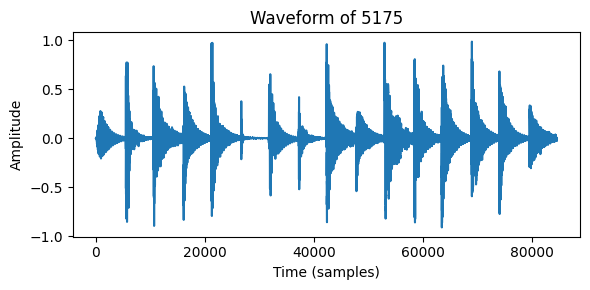

In [5]:
sample = train_labels.sample(1).iloc[0]

print(f"File: {sample['fname']}")
print(f"Labels: {sample['labels']}")

filepath = f"{DATA_PATH}/FSD50K.dev_audio/{sample['fname']}.wav"  # fix here

audio, sr = librosa.load(filepath, sr=None)
plt.figure(figsize=(6, 3))
plt.plot(audio)
plt.title(f"Waveform of {sample['fname']}")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

ipd.Audio(filepath)  # and here

In [6]:
#Function for extracting the spectrogram from an audio file, ensuring a fixed shape of (64, 216)
TARGET_SR = 22050                                       #Sample rate
DURATION = 5.0                                          #Seconds to keep (clip/pad to this length)
N_MELS = 64                                             #Number of mel bands to generate (bins in the spectrogram)
HOP_LENGTH = 512                                        #Number of samples between successive frames in the spectrogram
N_FRAMES = int(TARGET_SR * DURATION / HOP_LENGTH) + 1   #Number of frames in the spectrogram (~216 frames)

def extract_spectrogram(filepath):
    """Extracts a mel spectrogram from an audio file, ensuring a fixed shape of (64, 216).
    Inputs:
        filepath: Path to the audio file
    Outputs:
        mel_db: Mel spectrogram in decibels with shape (64, 216), or None if loading fails
    """
    try:
        audio, sr = librosa.load(filepath, sr=TARGET_SR, duration=DURATION, mono=True)
        
        # Pad if shorter than 5 seconds
        expected_samples = int(TARGET_SR * DURATION)
        if len(audio) < expected_samples:
            audio = np.pad(audio, (0, expected_samples - len(audio)))
        
        mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=N_MELS, hop_length=HOP_LENGTH)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        
        # Enforce fixed shape
        if mel_db.shape[1] < N_FRAMES:
            mel_db = np.pad(mel_db, ((0, 0), (0, N_FRAMES - mel_db.shape[1])))
        else:
            mel_db = mel_db[:, :N_FRAMES]
        
        return mel_db  # Shape: (64, 216)
    except:
        return None

In [7]:
print(f"Size of training data: {len(train_labels)}")
print(f"Unique combination of classes: {train_labels['labels'].nunique()}")
subset_percentage = 100
print(f"Using {subset_percentage}% of the training data equaling {int(len(train_labels) * subset_percentage / 100)} samples")
train_subset = train_labels.sample(n=int(len(train_labels) * subset_percentage / 100), random_state=42)

Size of training data: 36796
Unique combination of classes: 1043
Using 100% of the training data equaling 36796 samples


In [ ]:
#Run the function on a train
print("Extracting 2D spectrograms from train split...")
spectrograms = []
valid_idx = []  

for i, row in tqdm(train_subset.iterrows(), total=len(train_subset)):
    filepath = f"{DATA_PATH}/FSD50K.dev_audio/{row['fname']}.wav"
    spec = extract_spectrogram(filepath)
    if spec is not None:
        spectrograms.append(spec)
        valid_idx.append(i)

X_train = np.array(spectrograms)              # (n_clips, 64, 216)
X_train = X_train[:, np.newaxis, :, :]        # (n_clips, 1, 64, 216) — channel dim for CNN
train_true = train_subset.loc[valid_idx].reset_index(drop=True) # Keep only successfully processed samples

print(f"X_train shape: {X_train.shape}")

print(f"Number of successfully processed samples: {len(train_true)}")
print(f"Number of unsuccessful samples: {len(train_subset) - len(train_true)}")

Extracting 2D spectrograms from train split...


  0%|          | 0/36796 [00:00<?, ?it/s]

100%|██████████| 36796/36796 [03:54<00:00, 156.80it/s]


X_train shape: (36796, 1, 64, 216)


In [10]:
#Run the function on validation set
print("Extracting 2D spectrograms from validation split...")
spectrograms = []
valid_idx = []

for i, row in tqdm(val_labels.iterrows(), total=len(val_labels)):
    filepath = f"{DATA_PATH}/FSD50K.dev_audio/{row['fname']}.wav"
    spec = extract_spectrogram(filepath)
    if spec is not None:
        spectrograms.append(spec)
        valid_idx.append(i)

X_val = np.array(spectrograms)              # (n_clips, 64, 216)
X_val = X_val[:, np.newaxis, :, :]        # (n_clips, 1, 64, 216) — channel dim for CNN
val_true = val_labels.loc[valid_idx].reset_index(drop=True) # Keep only successfully processed samples

print(f"X_val shape: {X_val.shape}")

print(f"Number of successfully processed samples: {len(val_true)}")
print(f"Number of unsuccessful samples: {len(val_labels) - len(val_true)}")


Extracting 2D spectrograms from validation split...


100%|██████████| 4170/4170 [00:32<00:00, 129.80it/s]


X_val shape: (4170, 1, 64, 216)
Number of successfully processed samples: 4170
Number of unsuccessful samples: 0


In [11]:
import urllib.request
import json

url = "https://raw.githubusercontent.com/audioset/ontology/master/ontology.json"
urllib.request.urlretrieve(url, "ontology.json")

with open("ontology.json") as f:
    ontology = json.load(f)

# Build a lookup: mid → full entry
ontology_by_id = {entry["id"]: entry for entry in ontology}

# Build a reverse lookup: child_mid → parent_mid
child_to_parent = {}
for entry in ontology:
    for child_id in entry["child_ids"]:
        child_to_parent[child_id] = entry["id"]

# The 6 top-level family MIDs (updated to match the discovered ontology structure)
top_level = {
    "/m/0dgw9r": "Human sounds",
    "/m/0jbk":   "Animal",
    "/m/04rlf":  "Music",
    "/m/059j3w": "Natural sounds",
    "/t/dd00041": "Sounds of things",
    "/t/dd00098": "Source-ambiguous sounds",
}

def get_top_level_family(mid):
    current = mid
    while current not in top_level:
        parent = child_to_parent.get(current)
        if parent is None:
            return "Unknown"   # shouldn't happen for FSD50K classes
        current = parent
    return top_level[current]

train_true["family"] = train_true["mids"].apply(lambda x: get_top_level_family(x.split(",")[0]))
val_true["family"] = val_true["mids"].apply(lambda x: get_top_level_family(x.split(",")[0]))
print(train_true[["labels", "family"]].head())
print(val_true[["labels", "family"]].head())


                                      labels                   family
0                             Thump_and_thud  Source-ambiguous sounds
1                                 Mechanisms         Sounds of things
2               Breathing,Respiratory_sounds             Human sounds
3                      Finger_snapping,Hands             Human sounds
4  Meow,Cat,Domestic_animals_and_pets,Animal                   Animal
                                              labels family
0  Electric_guitar,Guitar,Plucked_string_instrume...  Music
1  Electric_guitar,Guitar,Plucked_string_instrume...  Music
2  Electric_guitar,Guitar,Plucked_string_instrume...  Music
3  Electric_guitar,Guitar,Plucked_string_instrume...  Music
4  Electric_guitar,Guitar,Plucked_string_instrume...  Music


In [12]:
#Test how many files belong to each family
family_counts_train = train_true["family"].value_counts()
print(family_counts_train)
print("Sum of all families in train set:", family_counts_train.sum(), "out of", len(train_true))
print("\n")

family_counts_val = val_true["family"].value_counts()
print(family_counts_val)
print("Sum of all families in val set:", family_counts_val.sum(), "out of", len(val_true))


family
Sounds of things           11669
Music                      11476
Human sounds                6540
Animal                      2684
Source-ambiguous sounds     2567
Natural sounds              1860
Name: count, dtype: int64
Sum of all families in train set: 36796 out of 36796


family
Sounds of things           1417
Music                      1117
Human sounds                759
Source-ambiguous sounds     451
Animal                      234
Natural sounds              192
Name: count, dtype: int64
Sum of all families in val set: 4170 out of 4170


In [13]:
le = LabelEncoder()
y_train = le.fit_transform(train_true["family"])

print(f"Classes: {len(le.classes_)}, y_train shape: {y_train.shape}")
print(train_true["family"].value_counts())
print("Sum of all families in train set:", family_counts_train.sum(), "out of", len(train_true))

Classes: 6, y_train shape: (36796,)
family
Sounds of things           11669
Music                      11476
Human sounds                6540
Animal                      2684
Source-ambiguous sounds     2567
Natural sounds              1860
Name: count, dtype: int64
Sum of all families in train set: 36796 out of 36796


In [14]:
class AudioCNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                        # (32, 32, 108)

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                        # (64, 16, 54)

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),      
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(256),  
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, n_classes)
        )

    def forward(self, x):
        return self.classifier(self.conv(x))

n_classes = len(le.classes_)
model = AudioCNN(n_classes)
print(model)

AudioCNN(
  (conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): LazyLinear(in_features=0, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=

In [ ]:
start_time = time.time()

n_classes = len(le.classes_)                                                                                    #Number of unique classes in the dataset
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")                                    #Use Apple Silicon GPU if available, otherwise CPU
model = AudioCNN(n_classes).to(device)                                                                          #Move model to the appropriate device (GPU or CPU)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)                                                       #Initialize Adam optimizer with a learning rate of 0.001
X_train_t = torch.tensor(X_train, dtype=torch.float32)                                                          #Convert training data to PyTorch tensor of type float32
y_train_t = torch.tensor(y_train, dtype=torch.long)                                                             #Convert training labels to PyTorch tensor of type long (integer class indices) 
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True, num_workers=6)      #Create DataLoader for batching and shuffling the training data
criterion = nn.CrossEntropyLoss()                                                                               #Use cross-entropy loss for multi-class classification       

print("Starting training...")

train_losses = []       #To save the average loss for each epoch for plotting later
EPOCHS = 25
for epoch in range(EPOCHS):                                                 
    epoch_start = time.time()                                                   #for ETA
    model.train()                                                               #Set model to training season
    total_loss, correct, total = 0, 0, 0                                        #to save the total loss and accuracy for the epoch
    for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):         #Iterate over batches of data
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (preds.argmax(1) == yb).sum().item()
        total += len(yb)

    epoch_time = time.time() - epoch_start
    epochs_remaining = EPOCHS - (epoch + 1)
    eta = epochs_remaining * epoch_time

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.3f} | Acc: {correct/total:.3f} | "
          f"Epoch time: {epoch_time:.1f}s | ETA: {eta/60:.1f} min")

print("My model is performing {:.1f} times better than random guess (Random Accuracy: {}).".format((correct/total) / (1/n_classes), 1/n_classes))

from datetime import datetime
end_time = time.time()
total_time = end_time - start_time
with open("Loss_and_Acc.txt", "a") as f: #Save loss and acc in a new line in txt file
    f.write(f"Final Accuracy: {correct/total:.3f}, Loss: {total_loss/len(train_loader):.3f}, Epochs: {EPOCHS}, batch_size: {train_loader.batch_size}, num_workers: {train_loader.num_workers}, Classes: {n_classes}, Number of samples: {len(train_loader.dataset)}, Runtime: {total_time/60:.1f} min, Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}\n")

plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss over epochs")
plt.show()

Starting training...


Epoch 1/25: 100%|██████████| 575/575 [02:20<00:00,  4.09it/s]


Epoch 01 | Loss: 1.509 | Acc: 0.509 | Epoch time: 140.7s | ETA: 56.3 min


Epoch 2/25: 100%|██████████| 575/575 [02:15<00:00,  4.24it/s]


Epoch 02 | Loss: 1.177 | Acc: 0.583 | Epoch time: 135.5s | ETA: 51.9 min


Epoch 3/25: 100%|██████████| 575/575 [02:00<00:00,  4.76it/s]


Epoch 03 | Loss: 1.098 | Acc: 0.606 | Epoch time: 120.9s | ETA: 44.3 min


Epoch 4/25:  49%|████▊     | 279/575 [01:00<01:12,  4.07it/s]